# CS 209 Final Project - Milestone 3

This notebook builds a two-stage CNN pipeline for hair follicle object modeling:

1. **Bounding box regressor** (`SmoothL1Loss`) trained on context crops around each annotated follicle.
2. **Label classifier** (`CrossEntropyLoss`) trained to classify each follicle into one of:
   - `single`
   - `premium`
   - `undersize`
   - `abnormal`

It includes:
- XML parsing (ported/adapted from Milestone 2)
- train/val split handling from `data/ImageSets/Main`
- model training + validation loops
- checkpointing best models by epoch
- pickle exports for metrics/history/metadata
- training curves (loss and accuracy/IoU)
- qualitative visualization of **predicted vs actual** boxes and labels on a sample image with multiple follicles

# Mount and Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import pickle
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# ---------------------------
# Reproducibility and device
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")


# ---------------------------
# Paths and experiment config
# ---------------------------
IS_COLAB = "COLAB_GPU" in os.environ or os.path.exists("/content")

if IS_COLAB:
    # Your actual Drive root (user-provided)
    ROOT = Path("/content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/").resolve()
    MS3_DIR = ROOT / "MS3"

    # Copy data to local Colab disk for faster XML/image I/O
    DRIVE_DATA_DIR = ROOT / "data"
    LOCAL_DATA_DIR = Path("/content/CS209B_data")
    if LOCAL_DATA_DIR.exists():
        print(f"Using existing local data cache: {LOCAL_DATA_DIR}")
    else:
        print(f"Copying data from Drive to local disk: {LOCAL_DATA_DIR}")
        shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)

    DATA_DIR = LOCAL_DATA_DIR

    # Save outputs to BOTH local runtime disk and Drive
    LOCAL_OUTPUT_DIR = Path("/content/CS209B_ms3_artifacts")
    DRIVE_OUTPUT_DIR = MS3_DIR / "artifacts"

else:
    CWD = Path.cwd().resolve()

    PROJECT_ROOT = None
    for candidate in [CWD, *CWD.parents]:
        if (candidate / "data").exists() and (candidate / "MS3").exists():
            PROJECT_ROOT = candidate
            break

    if PROJECT_ROOT is None:
        raise FileNotFoundError("Could not find project root containing both `data` and `MS3`.")

    ROOT = PROJECT_ROOT
    MS3_DIR = ROOT / "MS3"
    DATA_DIR = ROOT / "data"

    # Local dev: keep one output location
    LOCAL_OUTPUT_DIR = MS3_DIR / "artifacts"
    DRIVE_OUTPUT_DIR = LOCAL_OUTPUT_DIR

IMG_DIR = DATA_DIR / "Images"
ANN_DIR = DATA_DIR / "Annotations"
SPLIT_DIR = DATA_DIR / "ImageSets" / "Main"

OUTPUT_DIR = LOCAL_OUTPUT_DIR
MODELS_DIR = OUTPUT_DIR / "models"
HIST_DIR = OUTPUT_DIR / "history"
for p in [LOCAL_OUTPUT_DIR, DRIVE_OUTPUT_DIR, MODELS_DIR, HIST_DIR, DRIVE_OUTPUT_DIR / "models", DRIVE_OUTPUT_DIR / "history"]:
    p.mkdir(parents=True, exist_ok=True)


def _mirror_to_drive(local_path: Path):
    """Copy one local artifact file to Drive mirror location."""
    rel = local_path.relative_to(LOCAL_OUTPUT_DIR)
    drive_path = DRIVE_OUTPUT_DIR / rel
    drive_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(local_path, drive_path)
    return drive_path


def save_pickle_dual(obj, local_path: Path):
    with open(local_path, "wb") as f:
        pickle.dump(obj, f)
    drive_path = _mirror_to_drive(local_path)
    return local_path, drive_path


def save_torch_dual(obj, local_path: Path):
    torch.save(obj, local_path)
    drive_path = _mirror_to_drive(local_path)
    return local_path, drive_path


BOX_BATCH_SIZE = 32
CLS_BATCH_SIZE = 64
NUM_WORKERS = 4
BOX_EPOCHS = 5
CLS_EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4
CONTEXT_SCALE = 1.5

print(f"Running in Colab: {IS_COLAB}")
print(f"Project root: {ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Local output dir: {LOCAL_OUTPUT_DIR}")
print(f"Drive output dir: {DRIVE_OUTPUT_DIR}")
print(f"Images dir exists: {IMG_DIR.exists()}")
print(f"Annotations dir exists: {ANN_DIR.exists()}")
print(f"Split dir exists: {SPLIT_DIR.exists()}")
from pathlib import Path
ROOT = Path("/content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/")
print("ROOT exists:", ROOT.exists())
print("data exists:", (ROOT / "data").exists())
print("Annotations exists:", (ROOT / "data" / "Annotations").exists())
print("Images exists:", (ROOT / "data" / "Images").exists())

Using device: cuda
Using existing local data cache: /content/CS209B_data
Running in Colab: True
Project root: /content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect
Data dir: /content/CS209B_data
Local output dir: /content/CS209B_ms3_artifacts
Drive output dir: /content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/MS3/artifacts
Images dir exists: True
Annotations dir exists: True
Split dir exists: True
ROOT exists: True
data exists: True
Annotations exists: True
Images exists: True


# Data Processing

In [ ]:
# -------------------------------------------
# XML parsing
# -------------------------------------------
def parse_hair_follicle_xml(xml_file: Path):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    def get_text(parent, tag, default=None):
        elem = parent.find(tag) if parent is not None else None
        return elem.text.strip() if elem is not None and elem.text is not None else default

    source = root.find("source")
    size = root.find("size")

    data = {
        "folder": get_text(root, "folder"),
        "filename": get_text(root, "filename"),
        "database": get_text(source, "database"),
        "form": get_text(source, "form"),
        "image_source": get_text(source, "image"),
        "width": int(get_text(size, "width", 0)),
        "height": int(get_text(size, "height", 0)),
        "depth": int(get_text(size, "depth", 3)),
        "segmented": int(get_text(root, "segmented", 0)),
        "objects": [],
    }

    for obj in root.findall("object"):
        bndbox = obj.find("bndbox")
        xmin = int(get_text(bndbox, "xmin", 0))
        ymin = int(get_text(bndbox, "ymin", 0))
        xmax = int(get_text(bndbox, "xmax", 0))
        ymax = int(get_text(bndbox, "ymax", 0))

        object_data = {
            "class": get_text(obj, "class"),
            "pose": get_text(obj, "pose"),
            "difficult": int(get_text(obj, "difficult", 0)),
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "bbox_width": xmax - xmin,
            "bbox_height": ymax - ymin,
            "bbox_area": (xmax - xmin) * (ymax - ymin),
        }
        data["objects"].append(object_data)

    return data


def xml_to_object_rows(xml_file: Path):
    parsed = parse_hair_follicle_xml(xml_file)
    rows = []
    for obj in parsed["objects"]:
        rows.append(
            {
                "xml_file": str(xml_file),
                "folder": parsed["folder"],
                "filename": parsed["filename"],
                "width": parsed["width"],
                "height": parsed["height"],
                "depth": parsed["depth"],
                **obj,
            }
        )
    return rows


def parse_xml_folder(xml_dir: Path):
    rows = []
    for xml_file in sorted(xml_dir.glob("*.xml")):
        rows.extend(xml_to_object_rows(xml_file))
    return pd.DataFrame(rows)


def read_split_stems(split_file: Path):
    with open(split_file, "r", encoding="utf-8") as f:
        return set(line.strip() for line in f if line.strip())


def assign_splits(df: pd.DataFrame, split_dir: Path):
    train_stems = read_split_stems(split_dir / "train.txt")
    val_stems = read_split_stems(split_dir / "val.txt")
    test_stems = read_split_stems(split_dir / "test.txt")

    def get_split(fname):
        stem = Path(fname).stem
        if stem in train_stems:
            return "train"
        if stem in val_stems:
            return "val"
        if stem in test_stems:
            return "test"
        return "unassigned"

    out = df.copy()
    out["split"] = out["filename"].map(get_split)
    return out

In [ ]:
# -------------------------------------------
# Build object-level dataframe
# -------------------------------------------
annot_df = parse_xml_folder(ANN_DIR)
annot_df = assign_splits(annot_df, SPLIT_DIR)
annot_df["image_path"] = annot_df["filename"].map(lambda f: str(IMG_DIR / f))

# Keep only valid rows
annot_df = annot_df[(annot_df["bbox_width"] > 0) & (annot_df["bbox_height"] > 0)].copy()
annot_df = annot_df[annot_df["split"].isin(["train", "val", "test"])].copy()
annot_df = annot_df[annot_df["image_path"].map(lambda p: Path(p).exists())].copy()

# Class
CLASS_NAMES = ["single", "premium", "undersize", "abnormal"]
present_classes = sorted(annot_df["class"].unique().tolist())
for c in present_classes:
    if c not in CLASS_NAMES:
        CLASS_NAMES.append(c)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

annot_df["label_idx"] = annot_df["class"].map(CLASS_TO_IDX)

print(f"Total object samples: {len(annot_df):,}")
print("Split counts (object-level):")
print(annot_df["split"].value_counts())
print("\nClass counts:")
print(annot_df["class"].value_counts())

# Save metadata (local + Drive)
class_map_local, class_map_drive = save_pickle_dual(
    {"class_names": CLASS_NAMES, "class_to_idx": CLASS_TO_IDX},
    HIST_DIR / "class_mapping.pkl",
)
print(f"Saved class mapping: {class_map_local}")
print(f"Mirrored class mapping: {class_map_drive}")

annot_df.head()

Total object samples: 17,661
Split counts (object-level):
split
train    10477
test      3617
val       3567
Name: count, dtype: int64

Class counts:
class
premium      11875
single        4171
undersize     1222
abnormal       393
Name: count, dtype: int64
Saved class mapping: /content/CS209B_ms3_artifacts/history/class_mapping.pkl
Mirrored class mapping: /content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/MS3/artifacts/history/class_mapping.pkl


,xml_file,folder,filename,width,height,depth,class,pose,difficult,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,split,image_path,label_idx
1,/content/CS209B_data/Annotations/220105_A095_1...,data,220105_A095_1.jpg,1280,1024,3,premium,None,0,739,728,832,875,93,147,13671,val,/content/CS209B_data/Images/220105_A095_1.jpg,1
2,/content/CS209B_data/Annotations/220105_A095_1...,data,220105_A095_1.jpg,1280,1024,3,premium,None,0,702,780,784,872,82,92,7544,val,/content/CS209B_data/Images/220105_A095_1.jpg,1
3,/content/CS209B_data/Annotations/220105_A095_1...,data,220105_A095_1.jpg,1280,1024,3,premium,None,0,492,401,550,513,58,112,6496,val,/content/CS209B_data/Images/220105_A095_1.jpg,1
4,/content/CS209B_data/Annotations/220105_A095_1...,data,220105_A095_1.jpg,1280,1024,3,premium,None,0,449,473,569,588,120,115,13800,val,/content/CS209B_data/Images/220105_A095_1.jpg,1
5,/content/CS209B_data/Annotations/220105_A095_1...,data,220105_A095_1.jpg,1280,1024,3,premium,None,0,400,406,454,512,54,106,5724,val,/content/CS209B_data/Images/220105_A095_1.jpg,1


In [ ]:
# -------------------------------------------
# Geometry helpers + datasets
# -------------------------------------------
def clamp_box(xmin, ymin, xmax, ymax, w, h):
    xmin = max(0, min(int(round(xmin)), w - 1))
    ymin = max(0, min(int(round(ymin)), h - 1))
    xmax = max(xmin + 1, min(int(round(xmax)), w))
    ymax = max(ymin + 1, min(int(round(ymax)), h))
    return xmin, ymin, xmax, ymax


def make_context_box(gt_box, img_w, img_h, context_scale=1.5):
    xmin, ymin, xmax, ymax = gt_box
    bw = xmax - xmin
    bh = ymax - ymin
    cx = (xmin + xmax) / 2.0
    cy = (ymin + ymax) / 2.0

    cw = max(2.0, bw * context_scale)
    ch = max(2.0, bh * context_scale)

    ctx_xmin = cx - cw / 2.0
    ctx_ymin = cy - ch / 2.0
    ctx_xmax = cx + cw / 2.0
    ctx_ymax = cy + ch / 2.0

    return clamp_box(ctx_xmin, ctx_ymin, ctx_xmax, ctx_ymax, img_w, img_h)


def normalize_box_in_context(gt_box, ctx_box):
    gx1, gy1, gx2, gy2 = gt_box
    cx1, cy1, cx2, cy2 = ctx_box
    cw = max(1.0, cx2 - cx1)
    ch = max(1.0, cy2 - cy1)
    return np.array(
        [
            (gx1 - cx1) / cw,
            (gy1 - cy1) / ch,
            (gx2 - cx1) / cw,
            (gy2 - cy1) / ch,
        ],
        dtype=np.float32,
    )


def denormalize_box_in_context(norm_box, ctx_box):
    nx1, ny1, nx2, ny2 = norm_box
    cx1, cy1, cx2, cy2 = ctx_box
    cw = max(1.0, cx2 - cx1)
    ch = max(1.0, cy2 - cy1)
    return np.array(
        [
            cx1 + nx1 * cw,
            cy1 + ny1 * ch,
            cx1 + nx2 * cw,
            cy1 + ny2 * ch,
        ],
        dtype=np.float32,
    )


def box_iou_xyxy(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    inter_w = max(0.0, xB - xA)
    inter_h = max(0.0, yB - yA)
    inter = inter_w * inter_h

    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])
    union = area1 + area2 - inter + 1e-8
    return float(inter / union)


BOX_TRANSFORM = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

CLS_TRANSFORM = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class HairBoxRegressionDataset(Dataset):
    def __init__(self, df, transform=BOX_TRANSFORM, context_scale=1.5):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.context_scale = context_scale

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        w, h = img.size

        gt_box = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]
        ctx_box = make_context_box(gt_box, w, h, self.context_scale)

        crop = img.crop(ctx_box)
        x = self.transform(crop)

        target_box = normalize_box_in_context(gt_box, ctx_box)
        target_box = np.clip(target_box, 0.0, 1.0)

        return {
            "image": x,
            "target_box": torch.tensor(target_box, dtype=torch.float32),
            "gt_box": torch.tensor(gt_box, dtype=torch.float32),
            "ctx_box": torch.tensor(ctx_box, dtype=torch.float32),
        }


class HairLabelDataset(Dataset):
    def __init__(self, df, transform=CLS_TRANSFORM):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        w, h = img.size

        gt_box = clamp_box(row["xmin"], row["ymin"], row["xmax"], row["ymax"], w, h)
        crop = img.crop(gt_box)
        x = self.transform(crop)

        return {
            "image": x,
            "label": torch.tensor(int(row["label_idx"]), dtype=torch.long),
            "gt_box": torch.tensor(gt_box, dtype=torch.float32),
        }

# Baseline Models

In [ ]:
# -------------------------------------------
# Split data + dataloaders
# -------------------------------------------
train_df = annot_df[annot_df["split"] == "train"].copy()
val_df = annot_df[annot_df["split"] == "val"].copy()
test_df = annot_df[annot_df["split"] == "test"].copy()

print(f"Train objects: {len(train_df):,}")
print(f"Val objects:   {len(val_df):,}")
print(f"Test objects:  {len(test_df):,}")

box_train_ds = HairBoxRegressionDataset(train_df, context_scale=CONTEXT_SCALE)
box_val_ds = HairBoxRegressionDataset(val_df, context_scale=CONTEXT_SCALE)

cls_train_ds = HairLabelDataset(train_df)
cls_val_ds = HairLabelDataset(val_df)

box_train_loader = DataLoader(
    box_train_ds,
    batch_size=BOX_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
box_val_loader = DataLoader(
    box_val_ds,
    batch_size=BOX_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

cls_train_loader = DataLoader(
    cls_train_ds,
    batch_size=CLS_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
cls_val_loader = DataLoader(
    cls_val_ds,
    batch_size=CLS_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Dataloaders ready.")

Train objects: 10,477
Val objects:   3,567
Test objects:  3,617
Dataloaders ready.


In [ ]:
# -------------------------------------------
# Model definitions
# -------------------------------------------
def load_resnet18_backbone():
    # Try pretrained weights; fall back to random init if download is unavailable.
    try:
        return models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    except Exception as e:
        print(f"Warning: pretrained weights unavailable, using random init. ({e})")
        return models.resnet18(weights=None)


class BoxRegressorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = load_resnet18_backbone()
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 4),
            nn.Sigmoid(),  # normalized [0,1]
        )
        self.net = backbone

    def forward(self, x):
        out = self.net(x)
        # enforce x1<=x2 and y1<=y2 with sorting in forward pass
        x1 = torch.minimum(out[:, 0], out[:, 2])
        x2 = torch.maximum(out[:, 0], out[:, 2])
        y1 = torch.minimum(out[:, 1], out[:, 3])
        y2 = torch.maximum(out[:, 1], out[:, 3])
        return torch.stack([x1, y1, x2, y2], dim=1)


class LabelClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = load_resnet18_backbone()
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        self.net = backbone

    def forward(self, x):
        return self.net(x)


def evaluate_box_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_ious = []

    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(DEVICE)
            y = batch["target_box"].to(DEVICE)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)

            # Compute IoU in absolute image coordinates (not normalized crop coords).
            pred_np = pred.detach().cpu().numpy()
            y_np = y.detach().cpu().numpy()
            ctx_np = batch["ctx_box"].detach().cpu().numpy()

            for p_norm, t_norm, ctx in zip(pred_np, y_np, ctx_np):
                p_abs = denormalize_box_in_context(p_norm, ctx)
                t_abs = denormalize_box_in_context(t_norm, ctx)
                all_ious.append(box_iou_xyxy(p_abs, t_abs))

    avg_loss = total_loss / max(1, len(loader.dataset))
    avg_iou = float(np.mean(all_ious)) if all_ious else 0.0
    return avg_loss, avg_iou


def evaluate_cls_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    n = 0

    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(DEVICE)
            y = batch["label"].to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            n += x.size(0)

    avg_loss = total_loss / max(1, len(loader.dataset))
    acc = correct / max(1, n)
    return avg_loss, acc

In [ ]:
print(torch.cuda.get_device_name(0))

NVIDIA H100 80GB HBM3


[Box][Epoch 01/5] train_loss=0.0012 train_iou=0.8960 val_loss=0.0005 val_iou=0.8916
[Box][Epoch 02/5] train_loss=0.0006 train_iou=0.8482 val_loss=0.0006 val_iou=0.8484
[Box][Epoch 03/5] train_loss=0.0004 train_iou=0.8777 val_loss=0.0005 val_iou=0.8772
[Box][Epoch 04/5] train_loss=0.0004 train_iou=0.9490 val_loss=0.0003 val_iou=0.9486
[Box][Epoch 05/5] train_loss=0.0004 train_iou=0.8317 val_loss=0.0007 val_iou=0.8314
Saved best box model (local): /content/CS209B_ms3_artifacts/models/best_box_regressor.pt
Mirrored best box model (drive): /content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/MS3/artifacts/models/best_box_regressor.pt
Saved box history (local): /content/CS209B_ms3_artifacts/history/box_history.pkl
Mirrored box history (drive): /content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/MS3/artifacts/history/box_history.pkl


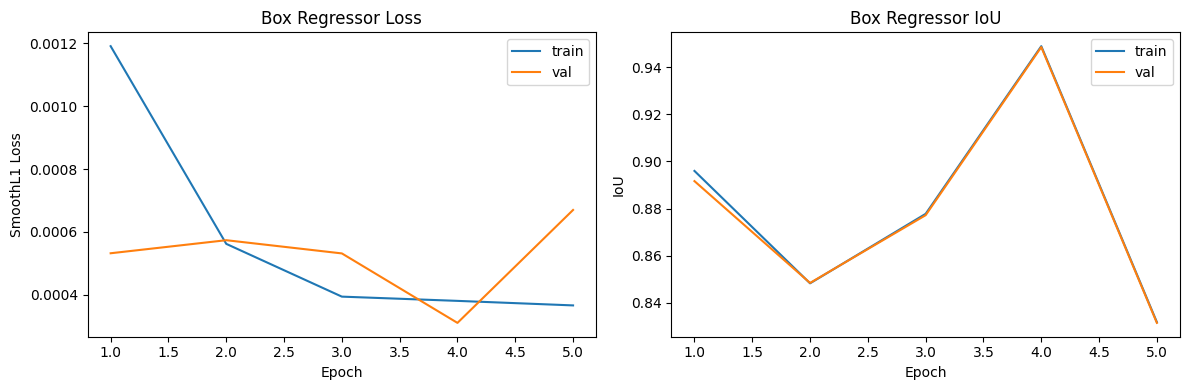

In [ ]:
# -------------------------------------------
# Train bounding-box regressor
# -------------------------------------------
box_model = BoxRegressorCNN().to(DEVICE)
box_criterion = nn.SmoothL1Loss()
box_optimizer = optim.Adam(box_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

box_history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": [],
}

best_box_val_loss = float("inf")
best_box_path = MODELS_DIR / "best_box_regressor.pt"

for epoch in range(1, BOX_EPOCHS + 1):
    box_model.train()
    running_loss = 0.0

    for batch in box_train_loader:
        x = batch["image"].to(DEVICE)
        y = batch["target_box"].to(DEVICE)

        box_optimizer.zero_grad()
        pred = box_model(x)
        loss = box_criterion(pred, y)
        loss.backward()
        box_optimizer.step()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / max(1, len(box_train_loader.dataset))
    train_eval_loss, train_iou = evaluate_box_model(box_model, box_train_loader, box_criterion)
    val_loss, val_iou = evaluate_box_model(box_model, box_val_loader, box_criterion)

    box_history["train_loss"].append(train_loss)
    box_history["val_loss"].append(val_loss)
    box_history["train_iou"].append(train_iou)
    box_history["val_iou"].append(val_iou)

    if val_loss < best_box_val_loss:
        best_box_val_loss = val_loss
        save_torch_dual(
            {
                "epoch": epoch,
                "model_state_dict": box_model.state_dict(),
                "optimizer_state_dict": box_optimizer.state_dict(),
                "val_loss": val_loss,
                "val_iou": val_iou,
            },
            best_box_path,
        )

    print(
        f"[Box][Epoch {epoch:02d}/{BOX_EPOCHS}] "
        f"train_loss={train_loss:.4f} train_iou={train_iou:.4f} "
        f"val_loss={val_loss:.4f} val_iou={val_iou:.4f}"
    )

box_hist_local, box_hist_drive = save_pickle_dual(box_history, HIST_DIR / "box_history.pkl")

print(f"Saved best box model (local): {best_box_path}")
print(f"Mirrored best box model (drive): {DRIVE_OUTPUT_DIR / 'models' / 'best_box_regressor.pt'}")
print(f"Saved box history (local): {box_hist_local}")
print(f"Mirrored box history (drive): {box_hist_drive}")

# Plot box metrics
epochs = np.arange(1, BOX_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, box_history["train_loss"], label="train")
axes[0].plot(epochs, box_history["val_loss"], label="val")
axes[0].set_title("Box Regressor Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("SmoothL1 Loss")
axes[0].legend()

axes[1].plot(epochs, box_history["train_iou"], label="train")
axes[1].plot(epochs, box_history["val_iou"], label="val")
axes[1].set_title("Box Regressor IoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].legend()

plt.tight_layout()
plt.show()

[Cls][Epoch 01/5] train_loss=0.5431 train_acc=0.7848 val_loss=0.5027 val_acc=0.8068
[Cls][Epoch 02/5] train_loss=0.4504 train_acc=0.8298 val_loss=0.4393 val_acc=0.8391
[Cls][Epoch 03/5] train_loss=0.4052 train_acc=0.8453 val_loss=0.4281 val_acc=0.8427
[Cls][Epoch 04/5] train_loss=0.3845 train_acc=0.8556 val_loss=0.4415 val_acc=0.8338
[Cls][Epoch 05/5] train_loss=0.3639 train_acc=0.8619 val_loss=0.4779 val_acc=0.8099
Saved best classifier model (local): /content/CS209B_ms3_artifacts/models/best_label_classifier.pt
Mirrored best classifier model (drive): /content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/MS3/artifacts/models/best_label_classifier.pt
Saved cls history (local): /content/CS209B_ms3_artifacts/history/cls_history.pkl
Mirrored cls history (drive): /content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/MS3/artifacts/history/cls_history.pkl


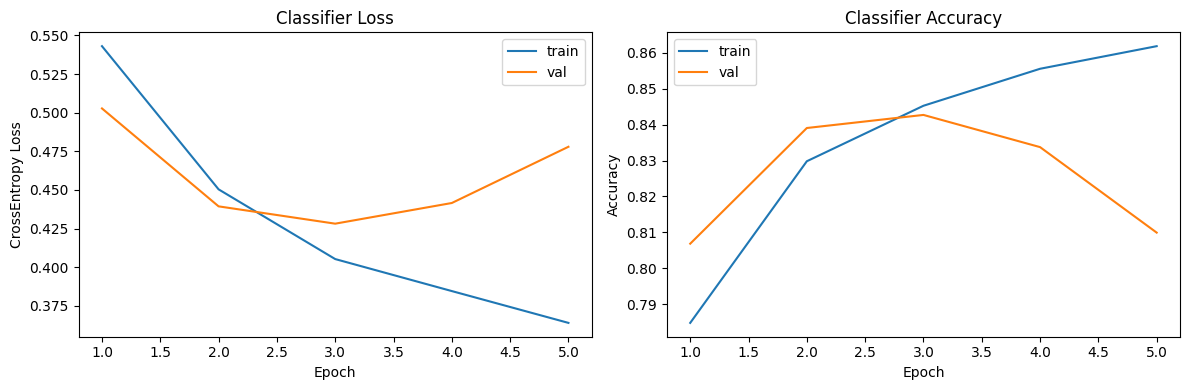

In [ ]:
# -------------------------------------------
# Train label classifier
# -------------------------------------------
cls_model = LabelClassifierCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
cls_criterion = nn.CrossEntropyLoss()
cls_optimizer = optim.Adam(cls_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

cls_history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_cls_val_acc = -1.0
best_cls_path = MODELS_DIR / "best_label_classifier.pt"

for epoch in range(1, CLS_EPOCHS + 1):
    cls_model.train()
    running_loss = 0.0
    running_correct = 0
    n_train = 0

    for batch in cls_train_loader:
        x = batch["image"].to(DEVICE)
        y = batch["label"].to(DEVICE)

        cls_optimizer.zero_grad()
        logits = cls_model(x)
        loss = cls_criterion(logits, y)
        loss.backward()
        cls_optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        n_train += x.size(0)

    train_loss = running_loss / max(1, len(cls_train_loader.dataset))
    train_acc = running_correct / max(1, n_train)
    val_loss, val_acc = evaluate_cls_model(cls_model, cls_val_loader, cls_criterion)

    cls_history["train_loss"].append(train_loss)
    cls_history["val_loss"].append(val_loss)
    cls_history["train_acc"].append(train_acc)
    cls_history["val_acc"].append(val_acc)

    if val_acc > best_cls_val_acc:
        best_cls_val_acc = val_acc
        save_torch_dual(
            {
                "epoch": epoch,
                "model_state_dict": cls_model.state_dict(),
                "optimizer_state_dict": cls_optimizer.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "class_names": CLASS_NAMES,
            },
            best_cls_path,
        )

    print(
        f"[Cls][Epoch {epoch:02d}/{CLS_EPOCHS}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

cls_hist_local, cls_hist_drive = save_pickle_dual(cls_history, HIST_DIR / "cls_history.pkl")

print(f"Saved best classifier model (local): {best_cls_path}")
print(f"Mirrored best classifier model (drive): {DRIVE_OUTPUT_DIR / 'models' / 'best_label_classifier.pt'}")
print(f"Saved cls history (local): {cls_hist_local}")
print(f"Mirrored cls history (drive): {cls_hist_drive}")

# Plot classifier metrics
epochs = np.arange(1, CLS_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, cls_history["train_loss"], label="train")
axes[0].plot(epochs, cls_history["val_loss"], label="val")
axes[0].set_title("Classifier Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()

axes[1].plot(epochs, cls_history["train_acc"], label="train")
axes[1].plot(epochs, cls_history["val_acc"], label="val")
axes[1].set_title("Classifier Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# Visualizing Results

In [ ]:
# -------------------------------------------
# Inference utilities for predicted boxes + labels
# -------------------------------------------
def predict_single_object(img_pil, gt_box, box_model, cls_model, context_scale=1.5):
    img_w, img_h = img_pil.size
    gt_box = clamp_box(*gt_box, img_w, img_h)

    # 1) Predict box from context crop around GT proposal
    ctx_box = make_context_box(gt_box, img_w, img_h, context_scale)
    ctx_crop = img_pil.crop(ctx_box)
    x_box = BOX_TRANSFORM(ctx_crop).unsqueeze(0).to(DEVICE)

    box_model.eval()
    cls_model.eval()

    with torch.no_grad():
        pred_norm = box_model(x_box).squeeze(0).cpu().numpy()

    pred_abs = denormalize_box_in_context(pred_norm, ctx_box)
    pred_abs = clamp_box(*pred_abs, img_w, img_h)

    # 2) Predict class from predicted crop
    pred_crop = img_pil.crop(pred_abs)
    x_cls = CLS_TRANSFORM(pred_crop).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = cls_model(x_cls)
        pred_idx = int(logits.argmax(dim=1).item())

    return pred_abs, pred_idx


def draw_gt_vs_pred_for_image(image_filename, image_df, box_model, cls_model, max_objects=40):
    image_path = IMG_DIR / image_filename
    img = Image.open(image_path).convert("RGB")

    sample_df = image_df.copy().reset_index(drop=True)
    if len(sample_df) > max_objects:
        sample_df = sample_df.sample(max_objects, random_state=SEED).reset_index(drop=True)

    preds = []
    gts = []

    for _, row in sample_df.iterrows():
        gt_box = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]
        pred_box, pred_idx = predict_single_object(
            img,
            gt_box,
            box_model,
            cls_model,
            context_scale=CONTEXT_SCALE,
        )

        gts.append({"box": gt_box, "label": row["class"]})
        preds.append({"box": pred_box, "label": IDX_TO_CLASS[pred_idx]})

    fig, ax = plt.subplots(figsize=(13, 10))
    ax.imshow(img)

    # GT boxes: solid green
    for gt in gts:
        x1, y1, x2, y2 = gt["box"]
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=1.6, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)

    # Pred boxes: dashed red
    for pr in preds:
        x1, y1, x2, y2 = pr["box"]
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1),
            w,
            h,
            linewidth=1.3,
            edgecolor="red",
            facecolor="none",
            linestyle="--",
        )
        ax.add_patch(rect)

    ax.set_title(
        f"GT (green) vs Predicted (red dashed) boxes | {image_filename} | objects={len(sample_df)}",
        fontsize=12,
    )
    ax.axis("off")
    plt.show()

    # Print side-by-side labels for quick sanity check
    compare_df = pd.DataFrame(
        {
            "gt_label": [g["label"] for g in gts],
            "pred_label": [p["label"] for p in preds],
        }
    )
    print("Per-object GT vs predicted labels (sample):")
    display(compare_df.head(20))

    label_acc = (compare_df["gt_label"] == compare_df["pred_label"]).mean()

    # IoU summary
    ious = [box_iou_xyxy(g["box"], p["box"]) for g, p in zip(gts, preds)]
    print(f"Sample image mean IoU: {np.mean(ious):.4f}")
    print(f"Sample image label accuracy: {label_acc:.4f}")

Loaded best box model from epoch 4 | val_loss=0.0003
Loaded best cls model from epoch 3 | val_acc=0.8427
Selected sample image: 230219_A135_3.jpg with 34 annotated objects


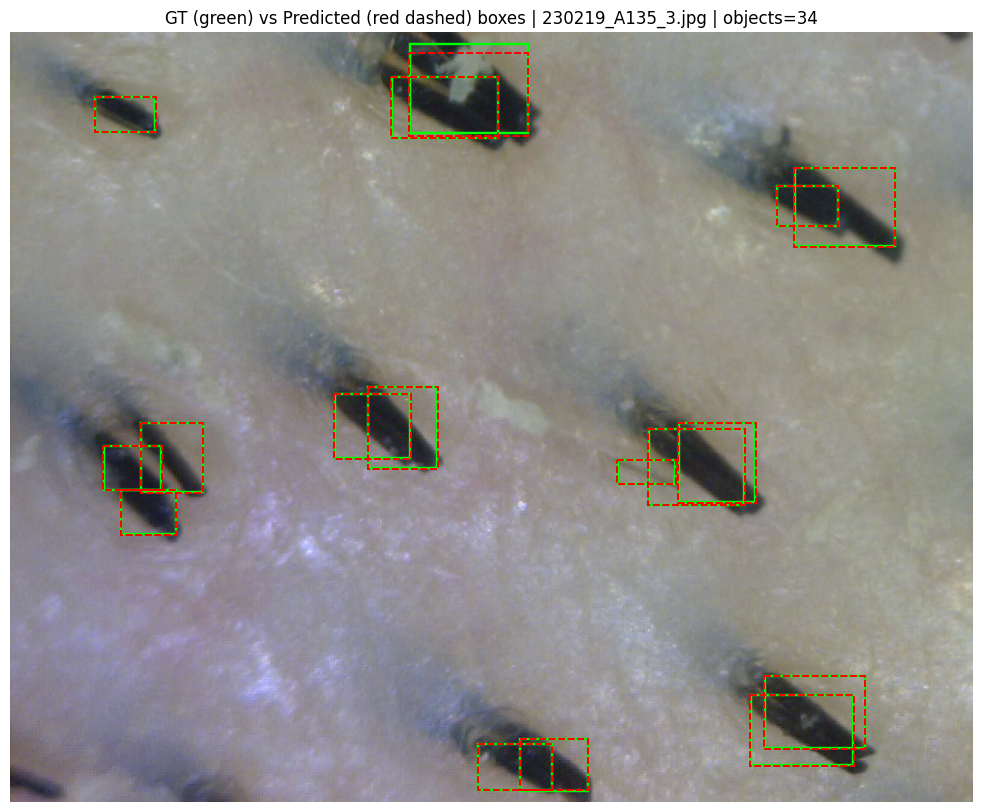

Per-object GT vs predicted labels (sample):


,gt_label,pred_label
0,premium,premium
1,premium,premium
2,premium,premium
3,premium,premium
4,premium,premium
5,premium,premium
6,premium,premium
7,premium,premium
8,premium,premium
9,premium,premium


Sample image mean IoU: 0.9699
Sample image label accuracy: 0.9412


In [ ]:
# -------------------------------------------
# Load best checkpoints and visualize one image
# -------------------------------------------
box_ckpt = torch.load(best_box_path, map_location=DEVICE)
cls_ckpt = torch.load(best_cls_path, map_location=DEVICE)

box_model.load_state_dict(box_ckpt["model_state_dict"])
cls_model.load_state_dict(cls_ckpt["model_state_dict"])

print(f"Loaded best box model from epoch {box_ckpt['epoch']} | val_loss={box_ckpt['val_loss']:.4f}")
print(f"Loaded best cls model from epoch {cls_ckpt['epoch']} | val_acc={cls_ckpt['val_acc']:.4f}")

# pick a validation image with many follicles for richer qualitative visualization
val_image_counts = val_df.groupby("filename").size().sort_values(ascending=False)
sample_image = val_image_counts.index[0]
print(f"Selected sample image: {sample_image} with {val_image_counts.iloc[0]} annotated objects")

sample_image_df = val_df[val_df["filename"] == sample_image].copy()
draw_gt_vs_pred_for_image(sample_image, sample_image_df, box_model, cls_model, max_objects=40)

# Error Analysis

Found image with wrong labels: 220105_A095_1.jpg


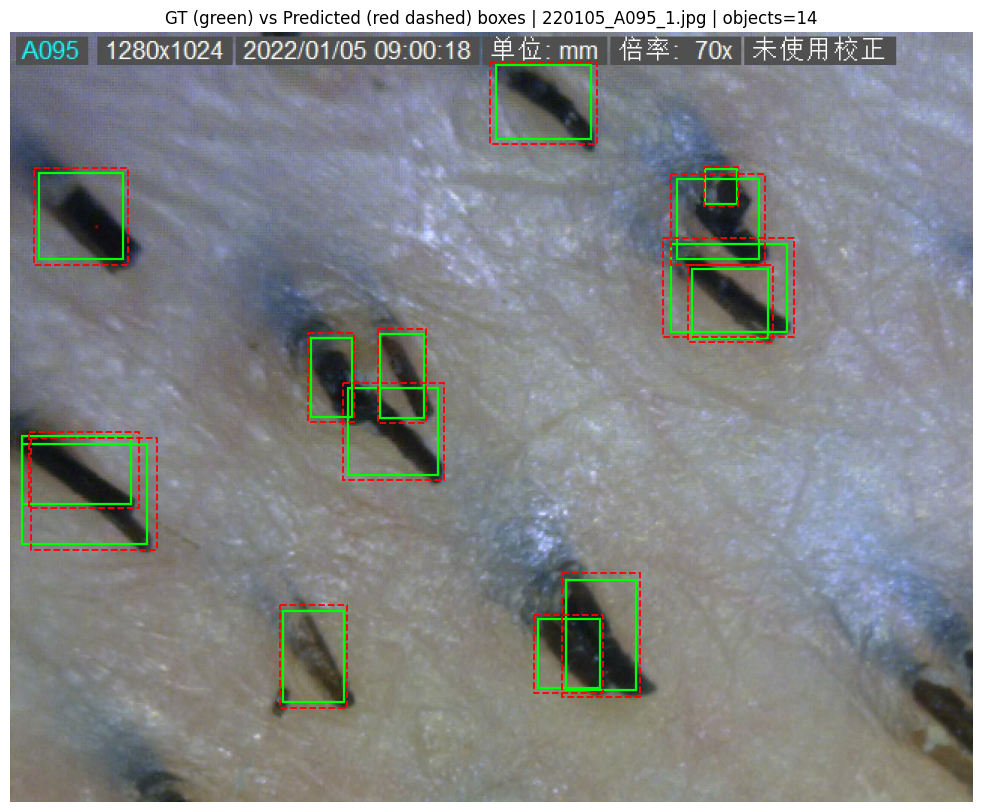

Per-object GT vs predicted labels (sample):


,gt_label,pred_label
0,premium,premium
1,premium,premium
2,premium,premium
3,premium,premium
4,premium,premium
5,premium,premium
6,premium,premium
7,single,premium
8,single,premium
9,premium,premium


Sample image mean IoU: 0.7961
Sample image label accuracy: 0.8571


,gt_label,pred_label,gt_box,pred_box
7,single,premium,"[646, 44, 772, 142]","(638, 39, 780, 148)"
8,single,premium,"[363, 769, 444, 891]","(358, 762, 448, 899)"


In [ ]:
# -------------------------------------------
# Error Analysis
# -------------------------------------------
def find_image_with_wrong_labels(val_df, box_model, cls_model, max_images=300, max_objects_per_image=60):
    grouped = val_df.groupby("filename")
    checked = 0

    for fname, gdf in grouped:
        if checked >= max_images:
            break
        checked += 1

        img = Image.open(IMG_DIR / fname).convert("RGB")
        work_df = gdf.copy().reset_index(drop=True)
        if len(work_df) > max_objects_per_image:
            work_df = work_df.sample(max_objects_per_image, random_state=SEED).reset_index(drop=True)

        rows = []
        for _, row in work_df.iterrows():
            gt_box = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]
            pred_box, pred_idx = predict_single_object(img, gt_box, box_model, cls_model, context_scale=CONTEXT_SCALE)
            pred_label = IDX_TO_CLASS[pred_idx]
            gt_label = row["class"]

            rows.append({
                "filename": fname,
                "gt_label": gt_label,
                "pred_label": pred_label,
                "is_wrong": pred_label != gt_label,
                "gt_box": gt_box,
                "pred_box": pred_box,
            })

        compare_df = pd.DataFrame(rows)
        if compare_df["is_wrong"].any():
            return fname, compare_df

    return None, None


# Find one image with wrong labels
wrong_image, compare_df = find_image_with_wrong_labels(val_df, box_model, cls_model)

if wrong_image is None:
    print("No wrong-label image found in searched subset.")
else:
    print(f"Found image with wrong labels: {wrong_image}")
    sample_image_df = val_df[val_df["filename"] == wrong_image].copy()

    # existing full overlay view
    draw_gt_vs_pred_for_image(wrong_image, sample_image_df, box_model, cls_model, max_objects=40)

    # print only wrong predictions
    wrong_only = compare_df[compare_df["is_wrong"]].copy()
    display(wrong_only[["gt_label", "pred_label", "gt_box", "pred_box"]].head(20))

Total evaluated objects: 3,567
Wrong labels: 589
Overall val classification accuracy: 0.8349


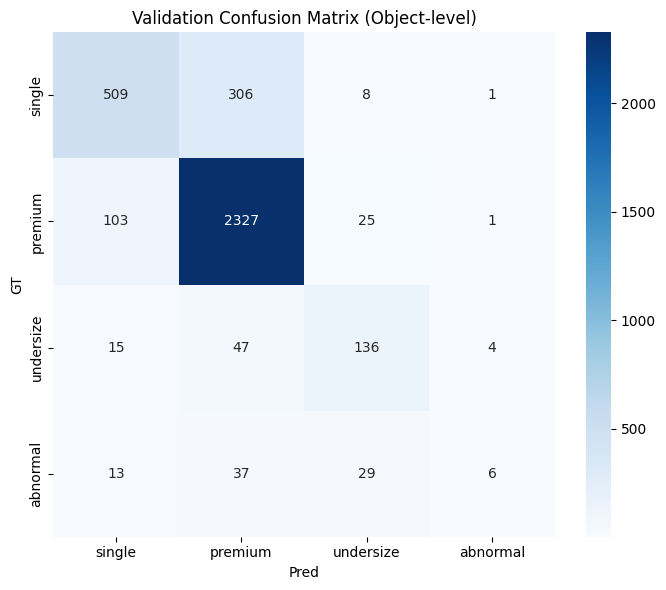

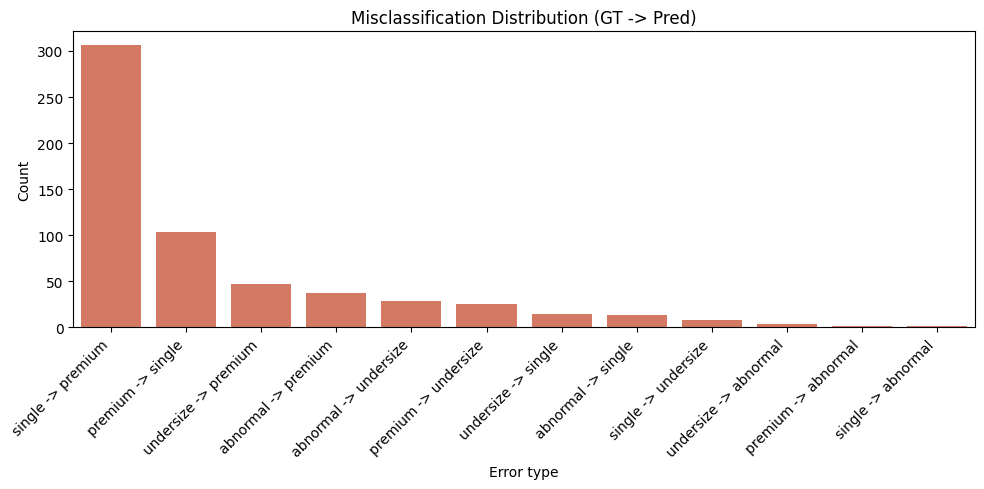

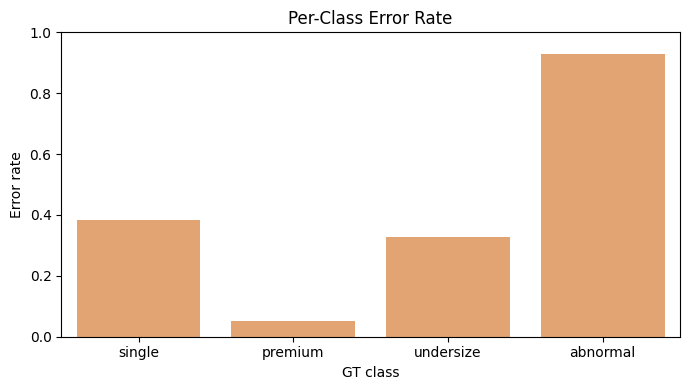


Top misclassification pairs:
error_pair
single -> premium        306
premium -> single        103
undersize -> premium      47
abnormal -> premium       37
abnormal -> undersize     29
premium -> undersize      25
undersize -> single       15
abnormal -> single        13
single -> undersize        8
undersize -> abnormal      4
Name: count, dtype: int64


In [ ]:
# -------------------------------------------
# Mislabel distribution + confusion matrix
# -------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

def build_val_predictions_table(val_df, box_model, cls_model, max_images=None, max_objects_per_image=None):
    rows = []
    grouped = val_df.groupby("filename")

    image_count = 0
    for fname, gdf in grouped:
        if max_images is not None and image_count >= max_images:
            break
        image_count += 1

        img = Image.open(IMG_DIR / fname).convert("RGB")
        work_df = gdf.copy().reset_index(drop=True)

        if max_objects_per_image is not None and len(work_df) > max_objects_per_image:
            work_df = work_df.sample(max_objects_per_image, random_state=SEED).reset_index(drop=True)

        for _, row in work_df.iterrows():
            gt_box = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]
            pred_box, pred_idx = predict_single_object(
                img, gt_box, box_model, cls_model, context_scale=CONTEXT_SCALE
            )
            pred_label = IDX_TO_CLASS[pred_idx]
            gt_label = row["class"]

            rows.append({
                "filename": fname,
                "gt_label": gt_label,
                "pred_label": pred_label,
                "is_wrong": pred_label != gt_label
            })

    return pd.DataFrame(rows)

# Build predictions table on full val set (or set max_images for quick run)
pred_df = build_val_predictions_table(
    val_df,
    box_model,
    cls_model,
    max_images=None,              # e.g. 200 for quicker pass
    max_objects_per_image=None    # e.g. 50 to cap per-image objects
)

print(f"Total evaluated objects: {len(pred_df):,}")
print(f"Wrong labels: {pred_df['is_wrong'].sum():,}")
print(f"Overall val classification accuracy: {(~pred_df['is_wrong']).mean():.4f}")

# 1) Confusion matrix (GT -> Pred)
cm = pd.crosstab(
    pred_df["gt_label"],
    pred_df["pred_label"],
    rownames=["GT"],
    colnames=["Pred"],
    dropna=False
).reindex(index=CLASS_NAMES, columns=CLASS_NAMES, fill_value=0)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix (Object-level)")
plt.tight_layout()
plt.show()

# 2) Wrong-label pair distribution: "GT -> Pred" for errors only
wrong_df = pred_df[pred_df["is_wrong"]].copy()

if len(wrong_df) == 0:
    print("No wrong labels found in evaluated subset.")
else:
    wrong_df["error_pair"] = wrong_df["gt_label"] + " -> " + wrong_df["pred_label"]
    pair_counts = wrong_df["error_pair"].value_counts()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=pair_counts.index, y=pair_counts.values, color="#e76f51")
    plt.xticks(rotation=45, ha="right")
    plt.title("Misclassification Distribution (GT -> Pred)")
    plt.xlabel("Error type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # 3) Per-GT class error rate bar chart
    gt_total = pred_df["gt_label"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    gt_wrong = wrong_df["gt_label"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    gt_err_rate = (gt_wrong / gt_total.replace(0, np.nan)).fillna(0.0)

    plt.figure(figsize=(7, 4))
    sns.barplot(x=gt_err_rate.index, y=gt_err_rate.values, color="#f4a261")
    plt.title("Per-Class Error Rate")
    plt.xlabel("GT class")
    plt.ylabel("Error rate")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    print("\nTop misclassification pairs:")
    print(pair_counts.head(10))

# Final Validation Metrics, Save and Download

In [ ]:
# -------------------------------------------
# Final validation metrics + save summary
# -------------------------------------------
box_val_loss, box_val_iou = evaluate_box_model(box_model, box_val_loader, box_criterion)
cls_val_loss, cls_val_acc = evaluate_cls_model(cls_model, cls_val_loader, cls_criterion)

summary = {
    "box_val_loss": box_val_loss,
    "box_val_iou": box_val_iou,
    "cls_val_loss": cls_val_loss,
    "cls_val_acc": cls_val_acc,
    "best_box_epoch": int(box_ckpt["epoch"]),
    "best_cls_epoch": int(cls_ckpt["epoch"]),
}

print("Validation summary:")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

summary_local, summary_drive = save_pickle_dual(summary, HIST_DIR / "final_summary.pkl")

print(f"Saved final summary pickle (local): {summary_local}")
print(f"Mirrored final summary pickle (drive): {summary_drive}")

Validation summary:
  box_val_loss: 0.0010
  box_val_iou: 0.7913
  cls_val_loss: 0.4281
  cls_val_acc: 0.8427
  best_box_epoch: 4
  best_cls_epoch: 3
Saved final summary pickle (local): /content/CS209B_ms3_artifacts/history/final_summary.pkl
Mirrored final summary pickle (drive): /content/drive/MyDrive/Senior/Spring/CS209B/CS209_Final_Pojrect/MS3/artifacts/history/final_summary.pkl


In [29]:
# -------------------------------------------
# Export and download artifacts folder (Colab-friendly)
# -------------------------------------------
from pathlib import Path
import shutil

artifacts_dir = Path(LOCAL_OUTPUT_DIR)
zip_base = Path("/content/CS209B_ms3_artifacts") if IS_COLAB else artifacts_dir.parent / "CS209B_ms3_artifacts"

if not artifacts_dir.exists():
    raise FileNotFoundError(f"Artifacts directory not found: {artifacts_dir}")

zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=str(artifacts_dir))
print(f"Created zip: {zip_path}")

if IS_COLAB:
    try:
        from google.colab import files
        files.download(zip_path)
        print("Download triggered in browser.")
    except Exception as e:
        print(f"Could not auto-download in this environment: {e}")
        print(f"You can manually download: {zip_path}")
else:
    print("Not running in Colab; zip created locally.")

Created zip: /content/CS209B_ms3_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered in browser.
